# Avaliação de Modelos - Projeto Vera (Desafio 1)
Este notebook documenta o processo de carregamento dos dados, treinamento do classificador de estilo (Camada N2 da Vera), avaliação das métricas e serialização do modelo.
A abordagem da Vera é **híbrida**, e aqui testamos o componente estatístico (Machine Learning Clássico) que trabalha em conjunto com o pipeline LLM.


In [1]:
import pandas as pd
from pathlib import Path
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt

# Normalização de acentos (Evitar que o modelo decore falta de acentos em fakes)
import unicodedata
def sem_acento(palavra: str) -> str:
    decomposto = unicodedata.normalize("NFD", palavra)
    return "".join(c for c in decomposto if not unicodedata.combining(c))


## 1. Carregamento dos Dados
Amostramos múltiplos datasets para evitar viés de assunto, priorizando o `fakewhatsapp-br` para robustez viral.

In [2]:
DIRETORIO_DATASETS = Path("../datasets")
CORPORA = ["fake-br", "FakeRecogna", "faketrue-br", "fakewhatsapp-br"]

partes = []
for slug in CORPORA:
    caminho = DIRETORIO_DATASETS / slug / "padronizado.parquet"
    if caminho.exists():
        df = pd.read_parquet(caminho)
        df = df[df["rotulo"].isin(["falso", "verdadeiro"])].dropna(subset=["texto"])
        df = df[df["texto"].str.split().str.len() >= 10]
        # Pegar amostragem para treinar rápido no notebook
        if len(df) > 5000:
            df = df.sample(5000, random_state=42)
        df = df[["texto", "rotulo"]].copy()
        df["corpus"] = slug
        partes.append(df)

dados = pd.concat(partes, ignore_index=True)
print(f"Total de registros carregados: {len(dados)}")
dados['rotulo'].value_counts()


Total de registros carregados: 18582


rotulo
verdadeiro    9503
falso         9079
Name: count, dtype: int64

## 2. Divisão de Treino e Teste
Usamos a separação estratificada garantindo que todos os corpora tenham a mesma proporção no treino e teste.

In [3]:
X = dados["texto"]
y = dados["rotulo"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=dados["corpus"] + "|" + dados["rotulo"]
)

print(f"Tamanho do Treino: {len(X_train)}")
print(f"Tamanho do Teste: {len(X_test)}")


Tamanho do Treino: 14865
Tamanho do Teste: 3717


## 3. Construção e Treinamento do Modelo (Pipeline)
O classificador usa TF-IDF combinado com Regressão Logística regularizada.

In [4]:
modelo = Pipeline([
    ("tfidf", TfidfVectorizer(
        strip_accents="unicode",
        lowercase=True,
        ngram_range=(1, 2),
        min_df=5,
        max_features=50_000,
        sublinear_tf=True
    )),
    ("classificador", LogisticRegression(
        max_iter=1000,
        C=4.0,
        class_weight="balanced",
        random_state=42
    ))
])

# Treinamento do modelo
print("Treinando o modelo...")
modelo.fit(X_train, y_train)
print("Treinamento concluído!")


Treinando o modelo...
Treinamento concluído!


## 4. Avaliação e Métricas
Avaliação de Acurácia, Relatório de Classificação e Matriz de Confusão para entender Falsos Positivos vs Falsos Negativos.

Acurácia Global: 90.29%
AUC Score: 0.961

=== Relatório de Classificação ===
              precision    recall  f1-score   support

       falso       0.88      0.92      0.90      1816
  verdadeiro       0.92      0.88      0.90      1901

    accuracy                           0.90      3717
   macro avg       0.90      0.90      0.90      3717
weighted avg       0.90      0.90      0.90      3717



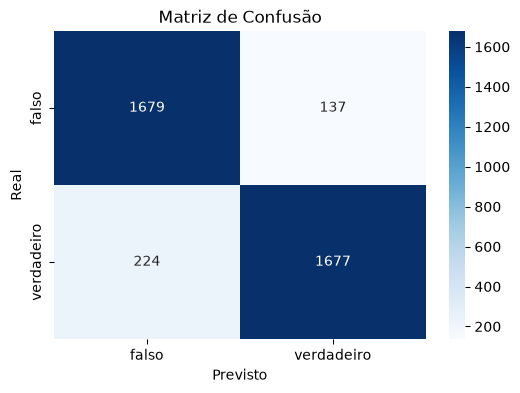

In [5]:
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, list(modelo.classes_).index("verdadeiro")]
y_test_bin = (y_test == "verdadeiro").astype(int)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test_bin, y_prob)

print(f"Acurácia Global: {acc * 100:.2f}%")
print(f"AUC Score: {auc:.3f}\n")

print("=== Relatório de Classificação ===")
print(classification_report(y_test, y_pred))

# Plot Matriz de Confusão
cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=modelo.classes_, yticklabels=modelo.classes_)
plt.title("Matriz de Confusão")
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()


## 5. Serialização do Modelo (.pkl / .joblib)
Exportando o modelo treinado para inferência direta pelo motor do backend.

In [6]:
caminho_modelo = Path("entrega_desafio/modelo_n2_estilo.pkl")
caminho_modelo.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(modelo, caminho_modelo)
tamanho_mb = caminho_modelo.stat().st_size / 1_000_000

print(f"Modelo salvo com sucesso em: {caminho_modelo}")
print(f"Tamanho do arquivo: {tamanho_mb:.2f} MB")


Modelo salvo com sucesso em: entrega_desafio/modelo_n2_estilo.pkl
Tamanho do arquivo: 2.39 MB
